# Estadística descriptiva por clase para variables Landsat 8 e índices espectrales

Calculo estadística descriptiva para variables espectrales e índices derivados de Landsat 8, por clase:

- `label = 0`: puntos sin incendio.
- `label = 1`: puntos con incendio.

Las variables analizadas son:

- `SR_B5`
- `SR_B6`
- `SR_B7`
- `NDVI`
- `EVI`
- `NBR`
- `NDWI`


In [1]:
# ============================================================
# 1. Importación de librerías
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

# Mostrar más columnas en pantalla
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

## 1. Definición de rutas

Se define la ruta del archivo CSV de entrada y se crea una carpeta de salida para guardar:

- Tablas de estadística descriptiva.
- Reportes de valores nulos.
- Histogramas.
- Boxplots.

In [4]:
# ============================================================
# 2. Definición de rutas de entrada y salida
# ============================================================

input_csv = Path(
    r"C:\Users\Equipo\Tesis\SemestreIV\Objetivo1\Objetivo1_26_02_20\outputs\outputs_rf_pipeline_260507-Copy1\dataset_A_complete_case_260507-Copy1.csv"
)

# Carpeta principal de salida
output_dir = input_csv.parent / "estadistica_descriptiva_landsat8_por_clase"
output_dir.mkdir(parents=True, exist_ok=True)

# Subcarpetas para tablas y figuras
tables_dir = output_dir / "tablas_csv"
figures_dir = output_dir / "figuras"
hist_dir = figures_dir / "histogramas"
box_dir = figures_dir / "boxplots"

tables_dir.mkdir(parents=True, exist_ok=True)
hist_dir.mkdir(parents=True, exist_ok=True)
box_dir.mkdir(parents=True, exist_ok=True)

print("Ruta de entrada:")
print(input_csv)

print("\nCarpeta de salida:")
print(output_dir)

Ruta de entrada:
C:\Users\Equipo\Tesis\SemestreIV\Objetivo1\Objetivo1_26_02_20\outputs\outputs_rf_pipeline_260507-Copy1\dataset_A_complete_case_260507-Copy1.csv

Carpeta de salida:
C:\Users\Equipo\Tesis\SemestreIV\Objetivo1\Objetivo1_26_02_20\outputs\outputs_rf_pipeline_260507-Copy1\estadistica_descriptiva_landsat8_por_clase


In [6]:
# ============================================================
# 3. Validación de existencia del archivo
# ============================================================

if not input_csv.exists():
    raise FileNotFoundError(
        f"No se encontró el archivo CSV en la ruta indicada:\n{input_csv}"
    )

print("Archivo encontrado correctamente.")

Archivo encontrado correctamente.


In [8]:
# ============================================================
# 4. Lectura segura del archivo CSV
# ============================================================

try:
    df = pd.read_csv(input_csv, sep=None, engine="python")
    print("Archivo CSV leído correctamente.")
except Exception as e:
    raise ValueError(
        f"No fue posible leer el archivo CSV. Revisa el separador, codificación o estructura del archivo.\n\nError original:\n{e}"
    )

print("\nDimensiones del archivo:")
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

display(df.head())

Archivo CSV leído correctamente.

Dimensiones del archivo:
Filas: 340
Columnas: 88


,idx_firms,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight,type,acq_date_n,anio,mes,dia,index_righ,MpNombre,Depto,mpnombre_s,depto_std,join_ok,fecha_FIRM,mpnombre_1,fecha_UNGR,dif_dias_m,dif_dias_a,tipo_coinc,fire_date,orb_same,img_same,idx_same,slice_same,orb_post30,img_post30,idx_post30,slice_post,orb_pre30,img_pre30,idx_pre30,slice_pre3,dt_post_da,dt_pre_day,label,id,point_id,SR_B5,SR_B6,SR_B7,NDVI,EVI,NBR,NDWI,VV,VH,angle,VVVH_ratio,VV_Difference,VH_Difference,VHVV_Difference,l8_found,l8_file,l8_year,l8_bimonth_start_month,l8_bimonth_label,l8_selection_rule,s1_found,s1_file,s1_date,s1_scene_index,SR_B5_norm,SR_B6_norm,SR_B7_norm,NDVI_norm,EVI_norm,NBR_norm,NDWI_norm,VV_norm,VH_norm,angle_norm,VVVH_ratio_norm,VV_Difference_norm,VH_Difference_norm,VHVV_Difference_norm
0,869.0,5.47858,-73.51540,298.48,0.38,0.36,2017-04-18,622.0,N,VIIRS,n,2.0,277.44,0.58,N,0.0,2017-04-18,2017.0,4.0,18.0,539.0,Samacá,Boyacá,SAMACA,BOYACA,1.0,2017-04-18,SAMACA,2017-04-14,4.0,4.0,ventana_5dias,2017-04-18,NaN,NaN,NaN,NaN,150.0,2017-05-14 00:00:00,25.0,6.0,150.0,2017-03-15 00:00:00,11.0,6.0,26.0,-34.0,1,NaN,209,0.354317,0.154227,0.074670,0.823090,0.558361,0.393456,-0.719667,-5.840342,-12.132593,32.312439,6.292252,0.863174,0.130650,-0.732524,True,L8_2017_may_jun.tif,2017,5,may_jun,next_bimonth,True,S1_2017-04-27_3_prepost_indices.tif,2017-04-27,3,0.682833,0.274355,0.114289,0.943446,0.830933,0.955272,0.173985,0.563349,0.535449,0.081165,0.328649,0.611186,0.545807,0.413302
1,893.0,5.48021,-73.52576,296.33,0.38,0.36,2017-04-18,622.0,N,VIIRS,n,2.0,276.78,0.73,N,2.0,2017-04-18,2017.0,4.0,18.0,539.0,Samacá,Boyacá,SAMACA,BOYACA,1.0,2017-04-18,SAMACA,2017-04-14,4.0,4.0,ventana_5dias,2017-04-18,NaN,NaN,NaN,NaN,150.0,2017-05-14 00:00:00,25.0,6.0,150.0,2017-03-15 00:00:00,11.0,6.0,26.0,-34.0,1,NaN,211,0.200015,0.139570,0.085285,0.640425,0.311379,0.177997,-0.633426,-9.578817,-14.608092,32.237587,5.029275,0.556598,-0.675132,-1.231730,True,L8_2017_may_jun.tif,2017,5,may_jun,next_bimonth,True,S1_2017-04-27_3_prepost_indices.tif,2017-04-27,3,0.334842,0.237080,0.137931,0.692934,0.443096,0.702653,0.313899,0.283538,0.375095,0.076140,0.146126,0.582783,0.430620,0.363129
2,898.0,5.47691,-73.52627,304.91,0.38,0.36,2017-04-18,622.0,N,VIIRS,n,2.0,278.98,0.73,N,2.0,2017-04-18,2017.0,4.0,18.0,539.0,Samacá,Boyacá,SAMACA,BOYACA,1.0,2017-04-18,SAMACA,2017-04-14,4.0,4.0,ventana_5dias,2017-04-18,NaN,NaN,NaN,NaN,150.0,2017-05-14 00:00:00,25.0,6.0,150.0,2017-03-15 00:00:00,11.0,6.0,26.0,-34.0,1,NaN,213,0.115645,0.099255,0.074037,0.477207,0.161682,0.076268,-0.485032,-9.315864,-14.834118,32.229107,5.518255,-0.040013,1.015787,1.055800,True,L8_2017_may_jun.tif,2017,5,may_jun,next_bimonth,True,S1_2017-04-27_3_prepost_indices.tif,2017-04-27,3,0.144567,0.134555,0.112881,0.469090,0.208024,0.583380,0.554645,0.303219,0.360454,0.075571,0.216792,0.527510,0.672339,0.593039
3,947.0,5.47059,-73.54893,309.29,0.38,0.36,2017-04-18,622.0,N,VIIRS,n,2.0,275.78,1.04,N,2.0,2017-04-18,2017.0,4.0,18.0,539.0,Samacá,Boyacá,SAMACA,BOYACA,1.0,2017-04-18,SAMACA,2017-04-14,4.0,4.0,ventana_5dias,2017-04-18,NaN,NaN,NaN,NaN,150.0,2017-05-14 00:00:00,25.0,6.0,150.0,2017-03-15 00:00:00,11.0,6.0,26.0,-34.0,1,NaN,217,0.110832,0.141467,0.208760,0.245536,0.098974,-0.121423,-0.263696,-8.688953,-14.780147,32.047634,6.091194,-1.016765,-0.462924,0.553841,True,L8_2017_may_jun.tif,2017,5,may_jun,next_bimonth,True,S1_2017-04-27_3_prepost_indices.tif,2017-04-27,3,0.133714,0.241905,0.412936,0.151369,0.109553,0.351594,0.913728,0.350141,0.363950,0.063388,0.299592,0.437020,0.460955,0.542589
4,1021.0,5.46507,-73.55687,298.37,0.38,0.36,2017-04-18,622.0,N,VIIRS,n,2.0,275.66,0.62,N,2.0,2017-04-18,2017.0,4.0,18.0,539.0,Samacá,Boyacá,SAMACA,BOYACA,1.0,2017-04-18,SAMACA,2017-04-14,4.0,4.0,ventana_5dias,2017-04-18,NaN,NaN,NaN,NaN,150.0,2017-05-14 00:00:00,25.0,6.0,150.0,2017-03-15 00:00:00,11.0,6.0,26.0,-34.0,1,NaN,228,0.113060,0.106102,0.080748,0.417058,0.138593,0.031

In [10]:
# ============================================================
# 5. Revisión de columnas disponibles
# ============================================================

print("Columnas disponibles en el archivo:")
for col in df.columns:
    print("-", col)

Columnas disponibles en el archivo:
- idx_firms
- latitude
- longitude
- brightness
- scan
- track
- acq_date
- acq_time
- satellite
- instrument
- confidence
- version
- bright_t31
- frp
- daynight
- type
- acq_date_n
- anio
- mes
- dia
- index_righ
- MpNombre
- Depto
- mpnombre_s
- depto_std
- join_ok
- fecha_FIRM
- mpnombre_1
- fecha_UNGR
- dif_dias_m
- dif_dias_a
- tipo_coinc
- fire_date
- orb_same
- img_same
- idx_same
- slice_same
- orb_post30
- img_post30
- idx_post30
- slice_post
- orb_pre30
- img_pre30
- idx_pre30
- slice_pre3
- dt_post_da
- dt_pre_day
- label
- id
- point_id
- SR_B5
- SR_B6
- SR_B7
- NDVI
- EVI
- NBR
- NDWI
- VV
- VH
- angle
- VVVH_ratio
- VV_Difference
- VH_Difference
- VHVV_Difference
- l8_found
- l8_file
- l8_year
- l8_bimonth_start_month
- l8_bimonth_label
- l8_selection_rule
- s1_found
- s1_file
- s1_date
- s1_scene_index
- SR_B5_norm
- SR_B6_norm
- SR_B7_norm
- NDVI_norm
- EVI_norm
- NBR_norm
- NDWI_norm
- VV_norm
- VH_norm
- angle_norm
- VVVH_ratio_nor

## 2. Definición de variables de interés

Las variables espectrales e índices seleccionados son:

- `SR_B5`: banda del infrarrojo cercano, NIR.
- `SR_B6`: banda SWIR 1.
- `SR_B7`: banda SWIR 2.
- `NDVI`: índice de vegetación de diferencia normalizada.
- `EVI`: índice de vegetación mejorado.
- `NBR`: índice normalizado de área quemada.
- `NDWI`: índice normalizado de agua o humedad.

La columna de clasificación es:

- `label`

In [13]:
# ============================================================
# 6. Definición de columnas requeridas
# ============================================================

variables = [
    "SR_B5",
    "SR_B6",
    "SR_B7",
    "NDVI",
    "EVI",
    "NBR",
    "NDWI"
]

label_col = "label"

required_columns = variables + [label_col]

missing_columns = [col for col in required_columns if col not in df.columns]

if missing_columns:
    raise ValueError(
        "Faltan las siguientes columnas requeridas en el archivo:\n"
        + "\n".join(missing_columns)
    )

print("Todas las columnas requeridas existen en el archivo.")

Todas las columnas requeridas existen en el archivo.


In [15]:
# ============================================================
# 7. Conversión de variables a formato numérico
# ============================================================

df_work = df.copy()

# Convertir variables espectrales e índices a numéricas
for col in variables:
    df_work[col] = pd.to_numeric(df_work[col], errors="coerce")

# Convertir label a numérico
df_work[label_col] = pd.to_numeric(df_work[label_col], errors="coerce")

print("Tipos de datos después de la conversión:")
display(df_work[required_columns].dtypes)

Tipos de datos después de la conversión:


SR_B5    float64
SR_B6    float64
SR_B7    float64
NDVI     float64
EVI      float64
NBR      float64
NDWI     float64
label      int64
dtype: object

In [17]:
# ============================================================
# 8. Validación de clases
# ============================================================

label_counts = df_work[label_col].value_counts(dropna=False).sort_index()

print("Frecuencia de valores en la columna label:")
display(label_counts)

expected_labels = {0, 1}
observed_labels = set(df_work[label_col].dropna().unique())

unexpected_labels = observed_labels - expected_labels

if unexpected_labels:
    print("Advertencia: se encontraron clases diferentes de 0 y 1:")
    print(unexpected_labels)
else:
    print("La columna label contiene únicamente las clases esperadas: 0 y 1.")

Frecuencia de valores en la columna label:


label
0    170
1    170
Name: count, dtype: int64

La columna label contiene únicamente las clases esperadas: 0 y 1.


In [19]:
# ============================================================
# 9. Filtrado de registros con label válido
# ============================================================

df_valid = df_work[df_work[label_col].isin([0, 1])].copy()

# Convertir label a entero para facilitar agrupaciones
df_valid[label_col] = df_valid[label_col].astype(int)

print("Dimensiones originales:")
print(df_work.shape)

print("\nDimensiones después de conservar label 0 y 1:")
print(df_valid.shape)

print("\nFrecuencia final por clase:")
display(df_valid[label_col].value_counts().sort_index())

Dimensiones originales:
(340, 88)

Dimensiones después de conservar label 0 y 1:
(340, 88)

Frecuencia final por clase:


label
0    170
1    170
Name: count, dtype: int64

In [21]:
# ============================================================
# 10. Valores nulos generales
# ============================================================

null_general = pd.DataFrame({
    "variable": variables,
    "n_nulos": [df_valid[col].isna().sum() for col in variables],
    "porcentaje_nulos": [df_valid[col].isna().mean() * 100 for col in variables]
})

null_general["porcentaje_nulos"] = null_general["porcentaje_nulos"].round(3)

display(null_general)

# Exportar reporte general de nulos
null_general.to_csv(
    tables_dir / "reporte_nulos_general.csv",
    index=False,
    encoding="utf-8-sig"
)

,variable,n_nulos,porcentaje_nulos
0,SR_B5,0,0.0
1,SR_B6,0,0.0
2,SR_B7,0,0.0
3,NDVI,0,0.0
4,EVI,0,0.0
5,NBR,0,0.0
6,NDWI,0,0.0


In [23]:
# ============================================================
# 11. Valores nulos por clase
# ============================================================

null_by_class_list = []

for label_value, group in df_valid.groupby(label_col):
    for col in variables:
        null_by_class_list.append({
            "label": label_value,
            "clase": "no_incendio" if label_value == 0 else "incendio",
            "variable": col,
            "n_total_clase": len(group),
            "n_nulos": group[col].isna().sum(),
            "porcentaje_nulos": group[col].isna().mean() * 100
        })

null_by_class = pd.DataFrame(null_by_class_list)
null_by_class["porcentaje_nulos"] = null_by_class["porcentaje_nulos"].round(3)

display(null_by_class)

# Exportar reporte de nulos por clase
null_by_class.to_csv(
    tables_dir / "reporte_nulos_por_clase.csv",
    index=False,
    encoding="utf-8-sig"
)

,label,clase,variable,n_total_clase,n_nulos,porcentaje_nulos
0,0,no_incendio,SR_B5,170,0,0.0
1,0,no_incendio,SR_B6,170,0,0.0
2,0,no_incendio,SR_B7,170,0,0.0
3,0,no_incendio,NDVI,170,0,0.0
4,0,no_incendio,EVI,170,0,0.0
5,0,no_incendio,NBR,170,0,0.0
6,0,no_incendio,NDWI,170,0,0.0
7,1,incendio,SR_B5,170,0,0.0
8,1,incendio,SR_B6,170,0,0.0
9,1,incendio,SR_B7,170,0,0.0


## 3. Función para calcular estadística descriptiva extendida

La siguiente función calcula:

- conteo
- media
- mediana
- desviación estándar
- mínimo
- máximo
- percentiles 5, 25, 50, 75 y 95
- rango
- rango intercuartílico
- coeficiente de variación
- asimetría
- curtosis

Debe interpretarse con precaución cuando la media está cerca de cero, especialmente en índices normalizados como NDVI, NBR o NDWI.

In [27]:
# ============================================================
# 12. Función para estadística descriptiva extendida
# ============================================================

def descriptive_stats_extended(dataframe, columns):
    """
    Calcula estadística descriptiva extendida para una lista de columnas numéricas.

    Parámetros
    ----------
    dataframe : pandas.DataFrame
        Tabla de entrada.
    columns : list
        Lista de columnas numéricas a analizar.

    Retorna
    -------
    pandas.DataFrame
        Tabla con estadísticos descriptivos por variable.
    """

    results = []

    for col in columns:
        series = dataframe[col].dropna()

        if series.empty:
            stats = {
                "variable": col,
                "count": 0,
                "mean": np.nan,
                "median": np.nan,
                "std": np.nan,
                "min": np.nan,
                "p05": np.nan,
                "p25": np.nan,
                "p50": np.nan,
                "p75": np.nan,
                "p95": np.nan,
                "max": np.nan,
                "range": np.nan,
                "iqr": np.nan,
                "cv": np.nan,
                "skewness": np.nan,
                "kurtosis": np.nan
            }
        else:
            mean_value = series.mean()
            std_value = series.std()

            # Evitar división por cero o medias muy cercanas a cero
            if np.isclose(mean_value, 0):
                cv_value = np.nan
            else:
                cv_value = std_value / mean_value

            stats = {
                "variable": col,
                "count": series.count(),
                "mean": mean_value,
                "median": series.median(),
                "std": std_value,
                "min": series.min(),
                "p05": series.quantile(0.05),
                "p25": series.quantile(0.25),
                "p50": series.quantile(0.50),
                "p75": series.quantile(0.75),
                "p95": series.quantile(0.95),
                "max": series.max(),
                "range": series.max() - series.min(),
                "iqr": series.quantile(0.75) - series.quantile(0.25),
                "cv": cv_value,
                "skewness": series.skew(),
                "kurtosis": series.kurtosis()
            }

        results.append(stats)

    return pd.DataFrame(results)

## 4. Estadística descriptiva general

Primero se calcula la estadística descriptiva sin separar por clase.  
Esto permite tener una visión global de la distribución de cada variable en todo el conjunto de datos.

In [30]:
# ============================================================
# 13. Estadística descriptiva general
# ============================================================

stats_general = descriptive_stats_extended(df_valid, variables)

# Redondear resultados para visualización
stats_general_rounded = stats_general.round(6)

display(stats_general_rounded)

# Exportar a CSV
stats_general_rounded.to_csv(
    tables_dir / "estadistica_descriptiva_general.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Estadística general exportada correctamente.")

,variable,count,mean,median,std,min,p05,p25,p50,p75,p95,max,range,iqr,cv,skewness,kurtosis
0,SR_B5,340,0.220432,0.202930,0.099260,0.051542,0.092175,0.134338,0.202930,0.294794,0.385186,0.494952,0.443410,0.160456,0.450297,0.502949,-0.640911
1,SR_B6,340,0.171187,0.155658,0.073075,0.046345,0.070867,0.114188,0.155658,0.220066,0.295408,0.439568,0.393223,0.105878,0.426870,0.693266,0.000751
2,SR_B7,340,0.113159,0.100933,0.059761,0.023355,0.047457,0.073766,0.100933,0.140811,0.224417,0.472347,0.448992,0.067045,0.528112,1.973695,7.117197
3,NDVI,340,0.549890,0.572533,0.179529,0.135164,0.224058,0.409139,0.572533,0.692864,0.800169,0.864327,0.729163,0.283725,0.326481,-0.387352,-0.838362
4,EVI,340,0.291549,0.265048,0.151879,0.029208,0.091146,0.163505,0.265048,0.415512,0.557108,0.666025,0.636817,0.252007,0.520939,0.442275,-0.774827
5,NBR,340,0.116380,0.125323,0.162883,-0.421298,-0.133299,0.000941,0.125323,0.242105,0.366994,0.431605,0.852903,0.241164,1.399576,-0.403359,0.024335
6,NDWI,340,-0.555721,-0.581065,0.138987,-0.826910,-0.741691,-0.663824,-0.581065,-0.454083,-0.299176,-0.210520,0.616390,0.209742,-0.250102,0.511418,-0.624071


Estadística general exportada correctamente.


## 4. Estadística descriptiva por clase

Ahora se calcula la estadística descriptiva separando por `label`. Esto permite comparar el comportamiento de cada banda o índice.

In [34]:
# ============================================================
# 14. Estadística descriptiva por clase
# ============================================================

stats_by_class_list = []

for label_value, group in df_valid.groupby(label_col):
    stats_temp = descriptive_stats_extended(group, variables)
    stats_temp.insert(0, "label", label_value)
    stats_temp.insert(
        1,
        "clase",
        "no_incendio" if label_value == 0 else "incendio"
    )
    stats_by_class_list.append(stats_temp)

stats_by_class = pd.concat(stats_by_class_list, ignore_index=True)

# Redondear resultados
stats_by_class_rounded = stats_by_class.round(6)

display(stats_by_class_rounded)

# Exportar a CSV
stats_by_class_rounded.to_csv(
    tables_dir / "estadistica_descriptiva_por_clase.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Estadística por clase exportada correctamente.")

,label,clase,variable,count,mean,median,std,min,p05,p25,p50,p75,p95,max,range,iqr,cv,skewness,kurtosis
0,0,no_incendio,SR_B5,170,0.286801,0.282178,0.081343,0.079730,0.167921,0.222173,0.282178,0.347140,0.437982,0.494952,0.415223,0.124967,0.283622,0.259910,-0.473973
1,0,no_incendio,SR_B6,170,0.210816,0.211476,0.070478,0.063615,0.099656,0.155492,0.211476,0.258322,0.335624,0.439568,0.375953,0.102829,0.334310,0.232849,-0.123843
2,0,no_incendio,SR_B7,170,0.123420,0.115721,0.054049,0.032760,0.051927,0.082391,0.115721,0.151309,0.226203,0.326982,0.294222,0.068918,0.437930,0.755497,0.463420
3,0,no_incendio,NDVI,170,0.623455,0.670820,0.159481,0.135164,0.309838,0.541766,0.670820,0.733364,0.813143,0.864327,0.729163,0.191598,0.255801,-0.967631,0.381662
4,0,no_incendio,EVI,170,0.385376,0.382006,0.132553,0.090971,0.162861,0.292695,0.382006,0.474742,0.608549,0.666025,0.575054,0.182047,0.343958,-0.056099,-0.590517
5,0,no_incendio,NBR,170,0.159601,0.181561,0.163009,-0.238077,-0.106189,0.043930,0.181561,0.281366,0.399296,0.431605,0.669682,0.237436,1.021357,-0.383052,-0.754998
6,0,no_incendio,NDWI,170,-0.613077,-0.644478,0.114967,-0.826910,-0.752420,-0.692958,-0.644478,-0.559845,-0.389928,-0.228875,0.598035,0.133113,-0.187525,0.986978,0.693625
7,1,incendio,SR_B5,170,0.154063,0.134524,0.065458,0.051542,0.084525,0.110214,0.134524,0.179211,0.300051,0.376510,0.324967,0.068998,0.424877,1.364767,1.684917
8,1,incendio,SR_B6,170,0.131559,0.120485,0.050841,0.046345,0.068488,0.097065,0.120485,0.155878,0.222443,0.353162,0.306817,0.058812,0.386455,1.352701,3.042657
9,1,incendio,SR_B7,170,0.102897,0.088688,0.063487,0.023355,0.044703,0.063976,0.088688,0.114710,0.210961,0.472347,0.448992,0.050734,0.616993,2.990554,12.749723


Estadística por clase exportada correctamente.


## 5. Tabla comparativa entre clases

Se genera una tabla comparativa donde cada variable muestra la media, mediana, desviación estándar y percentiles principales para ambas clases.

In [37]:
# ============================================================
# 15. Tabla comparativa resumida entre clases
# ============================================================

summary_metrics = ["mean", "median", "std", "p25", "p75", "p95"]

comparison_table = stats_by_class_rounded[
    ["label", "clase", "variable"] + summary_metrics
].copy()

display(comparison_table)

comparison_table.to_csv(
    tables_dir / "comparacion_resumida_por_clase.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Tabla comparativa exportada correctamente.")

,label,clase,variable,mean,median,std,p25,p75,p95
0,0,no_incendio,SR_B5,0.286801,0.282178,0.081343,0.222173,0.347140,0.437982
1,0,no_incendio,SR_B6,0.210816,0.211476,0.070478,0.155492,0.258322,0.335624
2,0,no_incendio,SR_B7,0.123420,0.115721,0.054049,0.082391,0.151309,0.226203
3,0,no_incendio,NDVI,0.623455,0.670820,0.159481,0.541766,0.733364,0.813143
4,0,no_incendio,EVI,0.385376,0.382006,0.132553,0.292695,0.474742,0.608549
5,0,no_incendio,NBR,0.159601,0.181561,0.163009,0.043930,0.281366,0.399296
6,0,no_incendio,NDWI,-0.613077,-0.644478,0.114967,-0.692958,-0.559845,-0.389928
7,1,incendio,SR_B5,0.154063,0.134524,0.065458,0.110214,0.179211,0.300051
8,1,incendio,SR_B6,0.131559,0.120485,0.050841,0.097065,0.155878,0.222443
9,1,incendio,SR_B7,0.102897,0.088688,0.063487,0.063976,0.114710,0.210961


Tabla comparativa exportada correctamente.


## 7. Histogramas por variable y por clase

Se generan histogramas para cada variable, comparando las distribuciones por clase

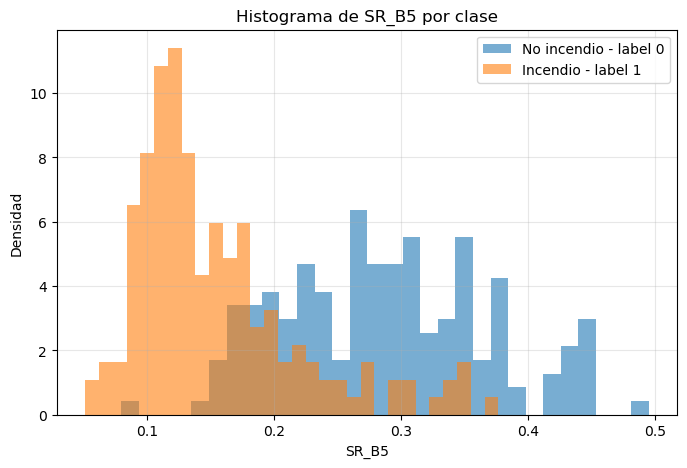

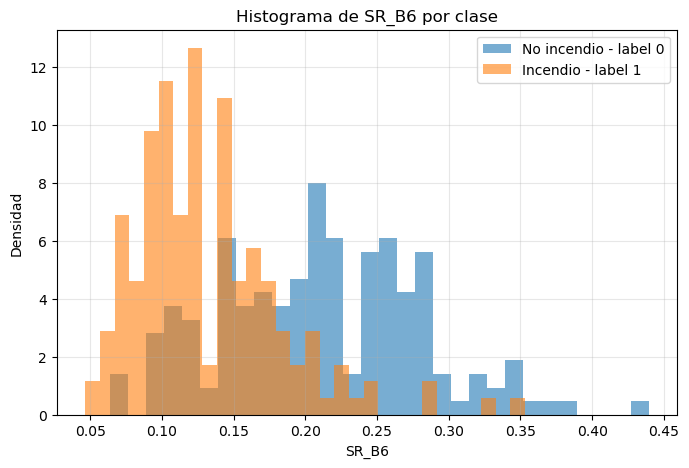

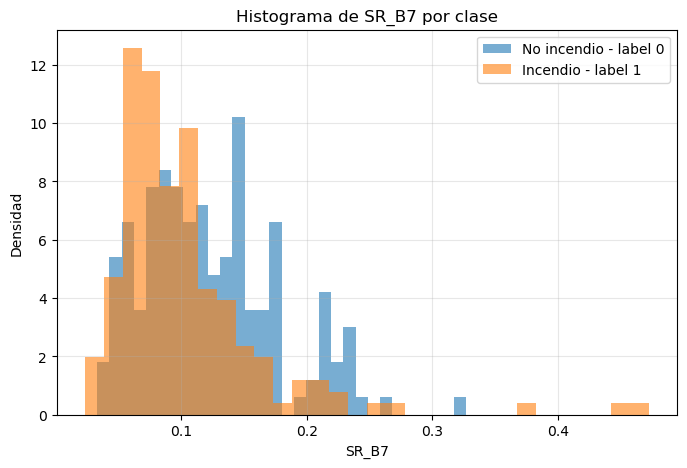

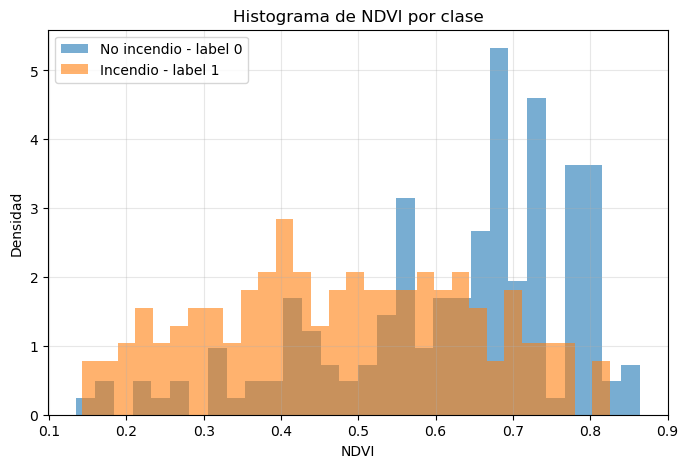

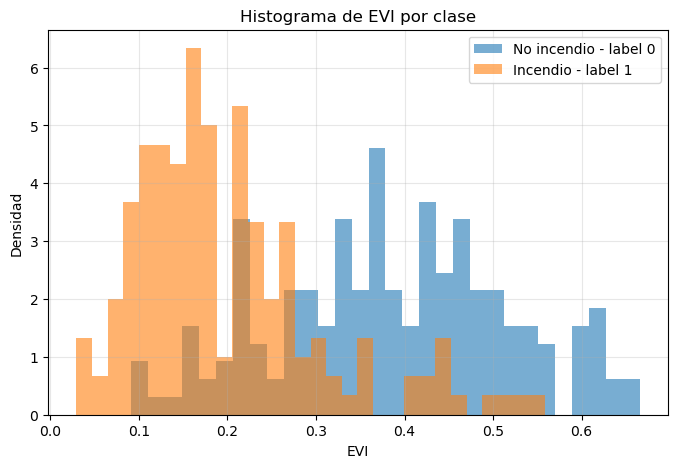

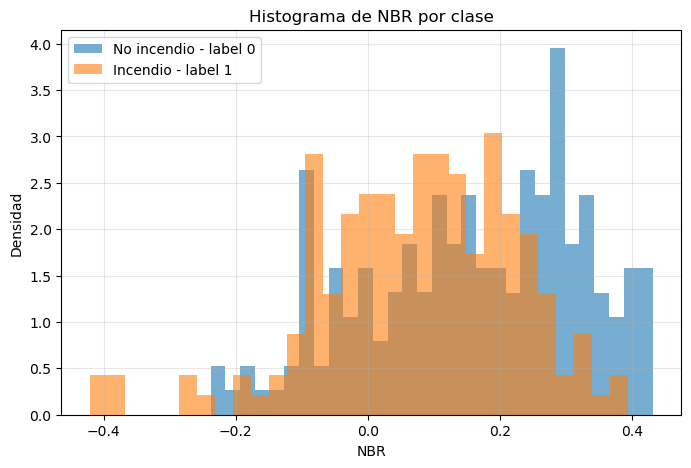

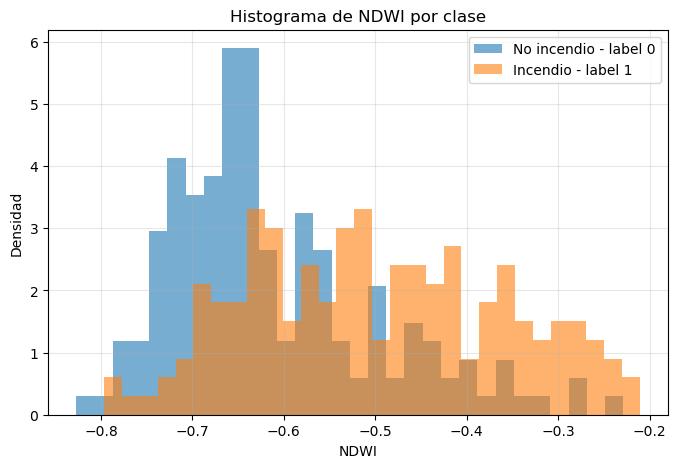

Histogramas generados y guardados correctamente.


In [40]:
# ============================================================
# 17. Histogramas por variable comparando clases
# ============================================================

for col in variables:
    plt.figure(figsize=(8, 5))

    data_0 = df_valid.loc[df_valid[label_col] == 0, col].dropna()
    data_1 = df_valid.loc[df_valid[label_col] == 1, col].dropna()

    plt.hist(
        data_0,
        bins=30,
        alpha=0.6,
        label="No incendio - label 0",
        density=True
    )

    plt.hist(
        data_1,
        bins=30,
        alpha=0.6,
        label="Incendio - label 1",
        density=True
    )

    plt.title(f"Histograma de {col} por clase")
    plt.xlabel(col)
    plt.ylabel("Densidad")
    plt.legend()
    plt.grid(True, alpha=0.3)

    output_fig = hist_dir / f"histograma_{col}_por_clase.png"
    plt.savefig(output_fig, dpi=300, bbox_inches="tight")

    plt.show()

print("Histogramas generados y guardados correctamente.")

## 7. Boxplots por variable y por clase

Los boxplots permiten comparar la distribución de cada variable entre clases.

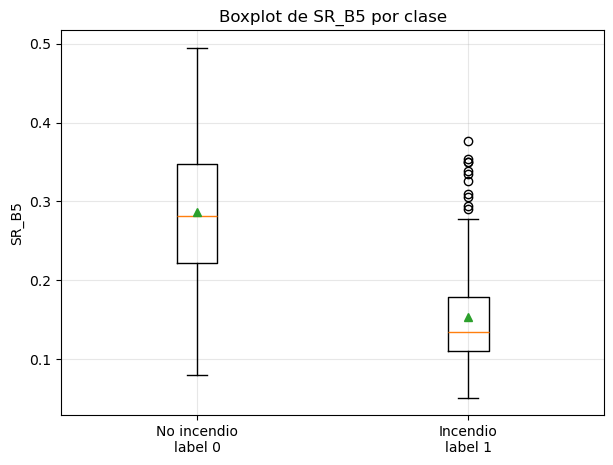

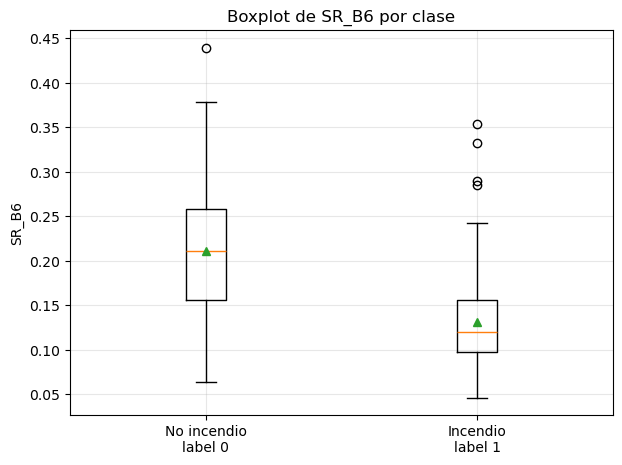

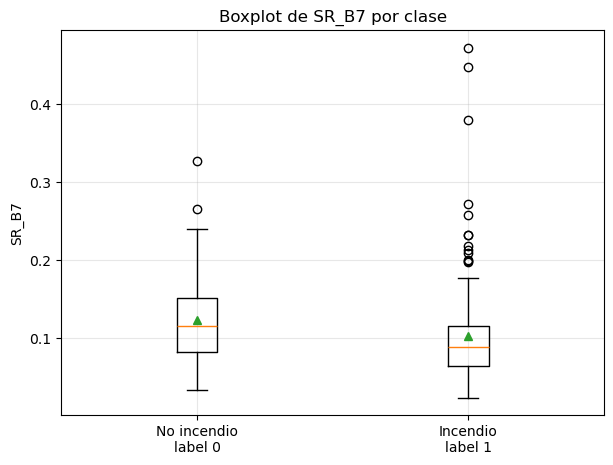

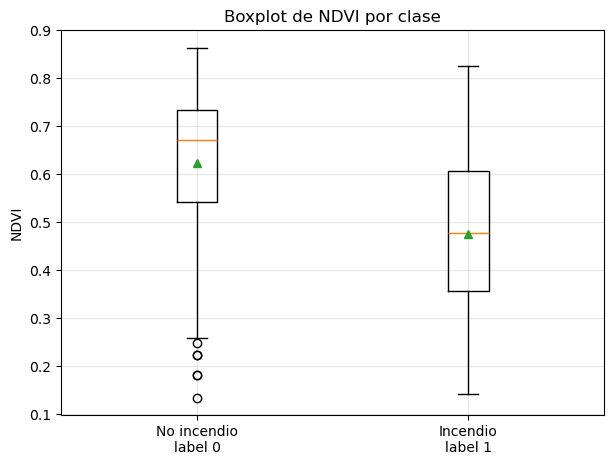

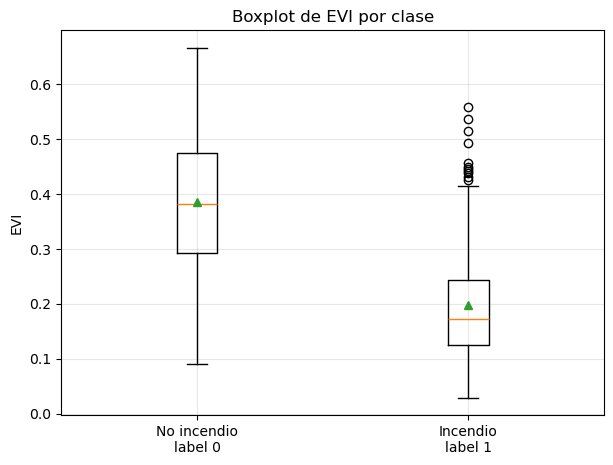

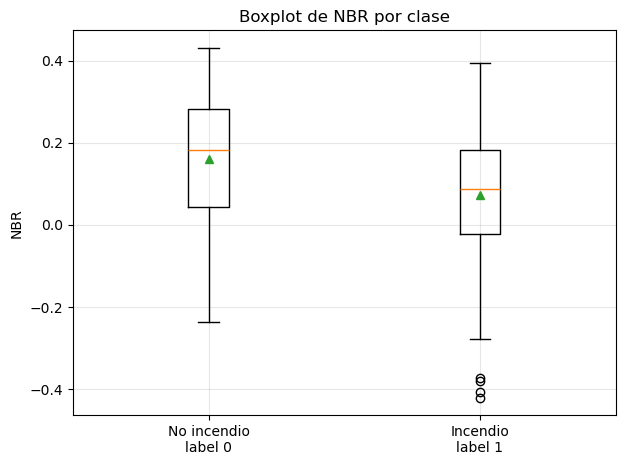

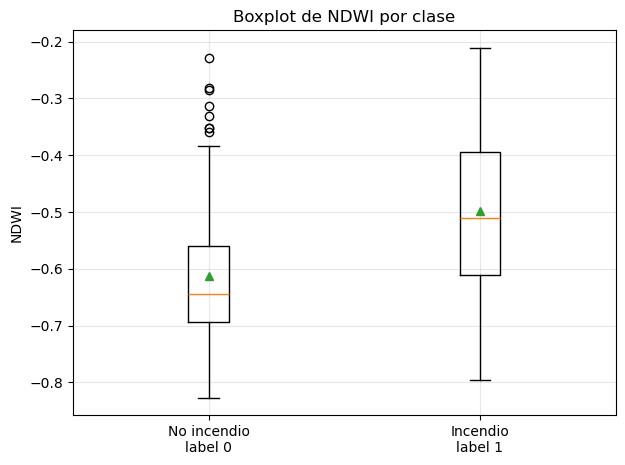

Boxplots generados y guardados correctamente.


In [43]:
# ============================================================
# 18. Boxplots por variable comparando clases
# ============================================================

for col in variables:
    data_0 = df_valid.loc[df_valid[label_col] == 0, col].dropna()
    data_1 = df_valid.loc[df_valid[label_col] == 1, col].dropna()

    plt.figure(figsize=(7, 5))

    plt.boxplot(
        [data_0, data_1],
        labels=["No incendio\nlabel 0", "Incendio\nlabel 1"],
        showmeans=True
    )

    plt.title(f"Boxplot de {col} por clase")
    plt.ylabel(col)
    plt.grid(True, alpha=0.3)

    output_fig = box_dir / f"boxplot_{col}_por_clase.png"
    plt.savefig(output_fig, dpi=300, bbox_inches="tight")

    plt.show()

print("Boxplots generados y guardados correctamente.")

## 8. Exportación consolidada de la base usada

Se exporta una copia de la base procesada con las variables seleccionadas y la columna `label`. Esto permite conservar el conjunto usado para la estadística descriptiva.

In [46]:
# ============================================================
# 20. Exportar base procesada usada en el análisis
# ============================================================

df_export = df_valid[[label_col] + variables].copy()

df_export.to_csv(
    tables_dir / "base_variables_landsat8_label_validada.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Base validada exportada correctamente.")

Base validada exportada correctamente.


In [48]:
# ============================================================
# 21. Resumen de salidas generadas
# ============================================================

print("Proceso finalizado.")
print("\nCarpeta principal de salida:")
print(output_dir)

print("\nCarpeta de tablas:")
print(tables_dir)

print("\nCarpeta de histogramas:")
print(hist_dir)

print("\nCarpeta de boxplots:")
print(box_dir)

Proceso finalizado.

Carpeta principal de salida:
C:\Users\Equipo\Tesis\SemestreIV\Objetivo1\Objetivo1_26_02_20\outputs\outputs_rf_pipeline_260507-Copy1\estadistica_descriptiva_landsat8_por_clase

Carpeta de tablas:
C:\Users\Equipo\Tesis\SemestreIV\Objetivo1\Objetivo1_26_02_20\outputs\outputs_rf_pipeline_260507-Copy1\estadistica_descriptiva_landsat8_por_clase\tablas_csv

Carpeta de histogramas:
C:\Users\Equipo\Tesis\SemestreIV\Objetivo1\Objetivo1_26_02_20\outputs\outputs_rf_pipeline_260507-Copy1\estadistica_descriptiva_landsat8_por_clase\figuras\histogramas

Carpeta de boxplots:
C:\Users\Equipo\Tesis\SemestreIV\Objetivo1\Objetivo1_26_02_20\outputs\outputs_rf_pipeline_260507-Copy1\estadistica_descriptiva_landsat8_por_clase\figuras\boxplots
